🦕 INITIALIZING TRICERATOPS FOR TIC 376866659...

1. Downloading and visualizing aperture...


C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


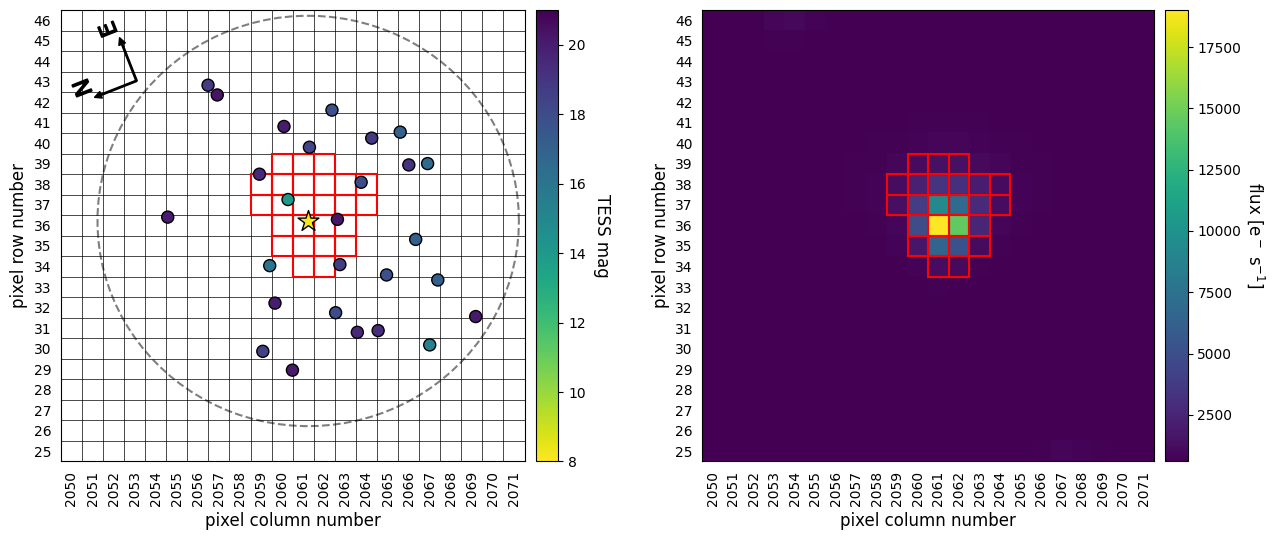

2. Calculating transit depths on nearby stars...
3. Running MCMC to calculate Final FPP (This may take a minute)...
griz mags: nan nan nan nan


C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\triceratops\funcs.py:377: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(output_url, delim_whitespace=True)


Calculating TP scenario probability for 376866659.
Calculating EB and EBx2P scenario probabilities for 376866659.
Z, Teff, logg: 0.0 6500 4.0
Calculating PTP scenario probability for 376866659.
Calculating PEB and PEBx2P scenario probabilities for 376866659.
Calculating STP scenario probability for 376866659.
Calculating SEB and SEBx2P scenario probabilities for 376866659.
Calculating DTP scenario probability for 376866659.
Calculating DEB and DEBx2P scenario probabilities for 376866659.
Calculating BTP scenario probability for 376866659.
Calculating BEB and BEBx2P scenario probabilities for 376866659.

🎯 FINAL VALIDATION RESULTS:
FPP  (False Positive Prob): 0.000000
NFPP (Nearby FP Prob):      0.000000
✅ STATUS: VALIDATED PLANET (FPP < 1%)
📊 Plotting model fits...


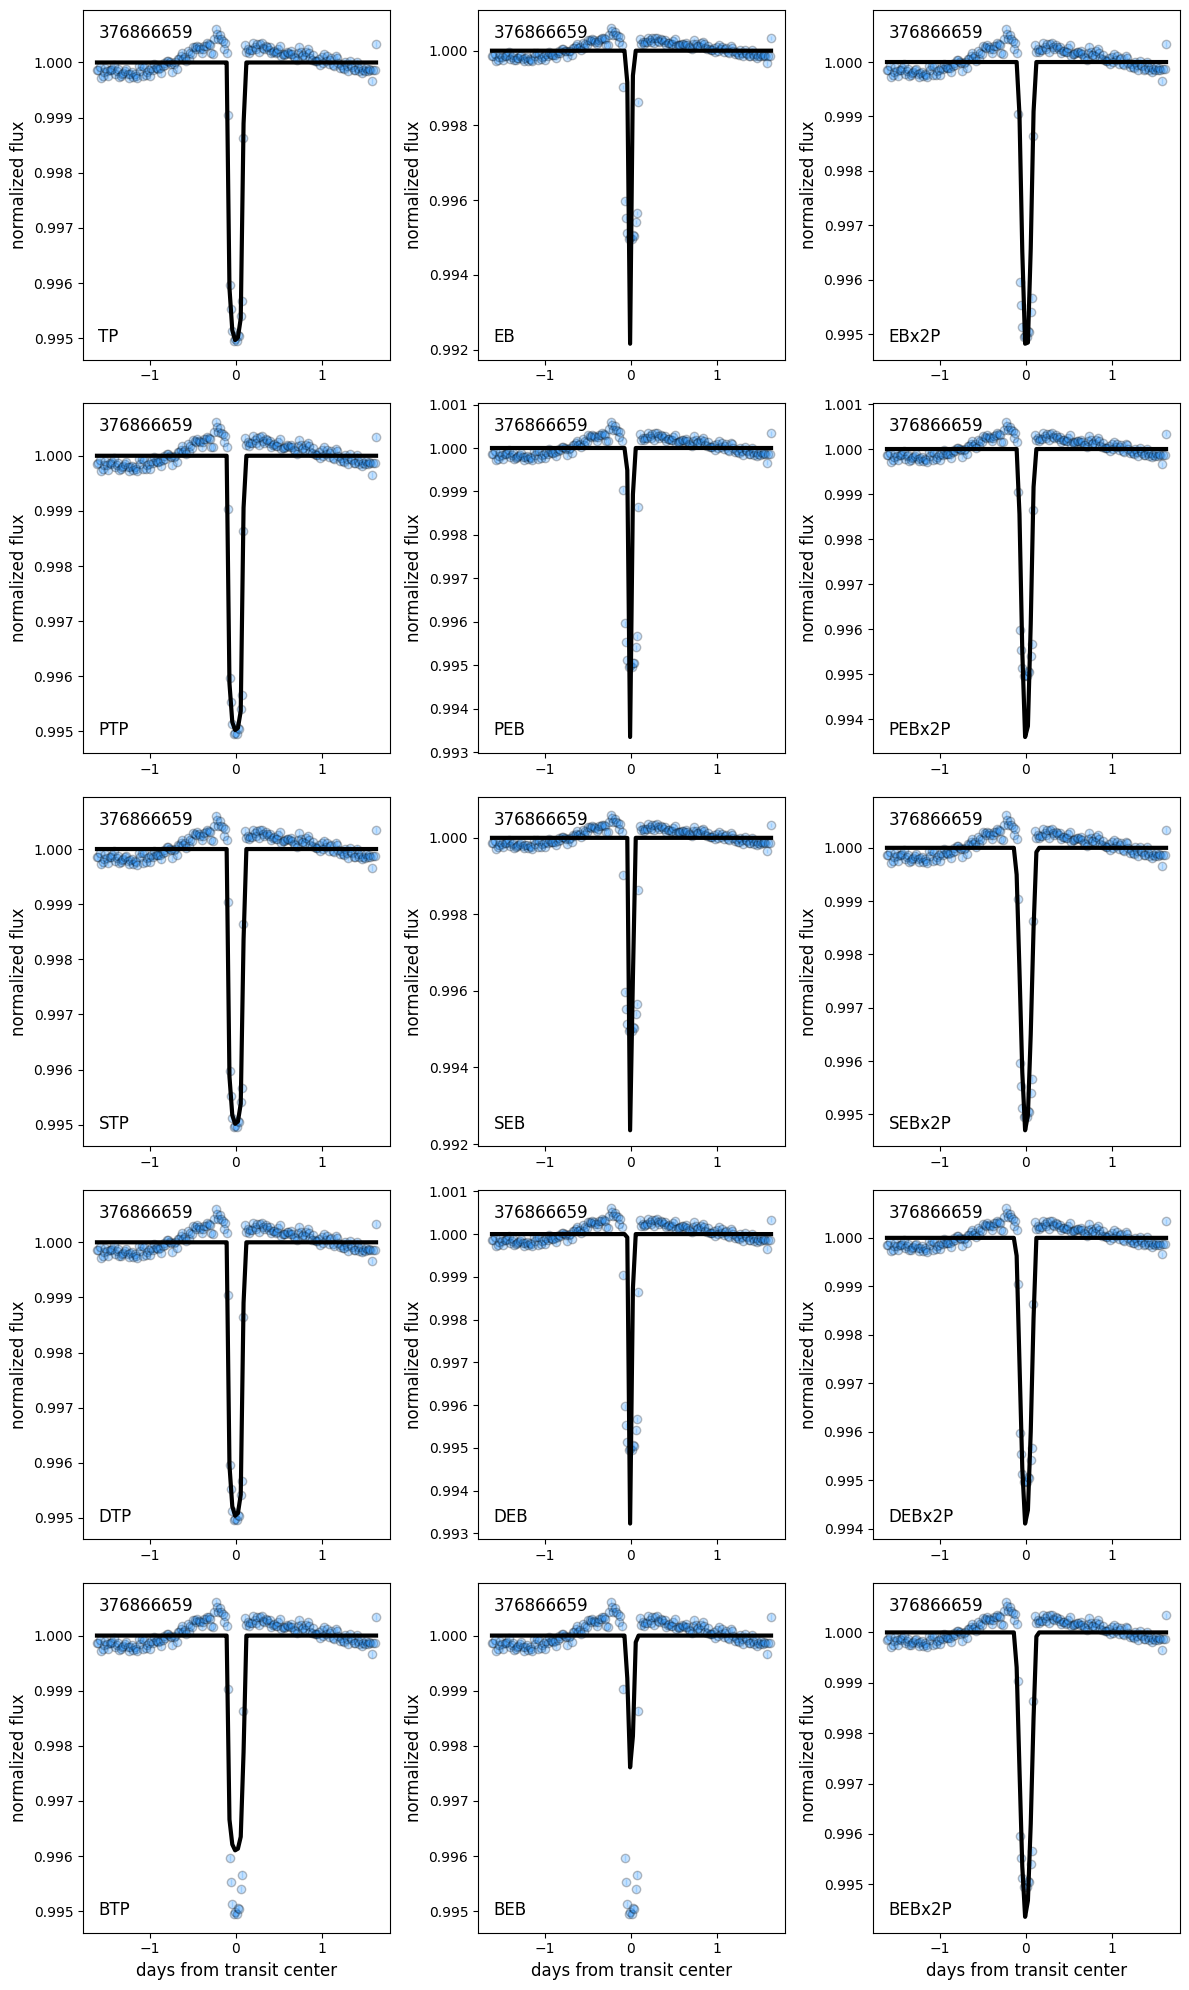


--- 🌟 STAR FIELD ANALYSIS (Stars inside aperture) ---
           ID    Bmag     Vmag      Tmag    Jmag    Hmag    Kmag     gmag  \
0   376866659   9.029   8.5620   8.14481   7.676   7.480   7.451      NaN   
1   376866658  17.238  14.8810  13.99620  13.177  12.703  12.569  15.2734   
2   953314063     NaN  20.8893  20.26280     NaN     NaN     NaN      NaN   
3   953314062     NaN  20.2812  18.70010     NaN     NaN     NaN  21.2448   
4   376866655  18.278  16.8644  15.99420  15.209  14.667  14.372  17.3343   
5   376866662  20.523  19.6324  17.96950  16.559  15.687  15.449  20.4140   
6   953314066     NaN  20.6162  19.53390     NaN     NaN     NaN      NaN   
7   953314057     NaN  19.6416  18.28280     NaN     NaN     NaN  20.2675   
8   953314069     NaN  20.9890  19.99500     NaN     NaN     NaN      NaN   
9   953314060     NaN  18.7178  17.98760     NaN     NaN     NaN  19.1053   
10  376856686  20.679  19.5859  17.84300  16.344  15.701  15.161  20.3564   
11  953314058     NaN

In [3]:
"""
03_triceratops_vetting_7475.01.ipynb
=============================================================================
TRICERATOPS STATISTICAL VALIDATION
=============================================================================

DESCRIPTION:
    This script performs a rigorous statistical validation of the planet candidate
    TOI 7475.01 (TIC 376866659) using the 'triceratops' library.
    
    It calculates two key metrics:
    1. FPP (False Positive Probability): The chance the signal is NOT a planet.
    2. NFPP (Nearby False Positive Probability): The chance the signal comes 
       from a nearby background star.

AUTHOR: Biel Escolà Rodrigo
TARGET: TOI 7475.01 (TIC 376866659)
"""

import numpy as np
import pandas as pd
import lightkurve as lk
import matplotlib.pyplot as plt
import triceratops.triceratops as tr
import os 

# --- 1. CONFIGURATION ---
TIC_ID = 376866659          
SECTORS = np.array([91])    
TRANSIT_DEPTH = 0.0050      # Derived from your BLS analysis (approx 5000 ppm)
ORBITAL_PERIOD = 3.252637   # Your detected period

# Filename of the data generated in script 01 (Check exact name in your folder!)
# Note: Ensure this CSV exists in the same folder.
INPUT_FILE = "TOI7475.01_Folded_Raw_GrayPoints.csv" 

print(f"🦕 INITIALIZING TRICERATOPS FOR TIC {TIC_ID}...")

# Initialize the target object
target = tr.target(ID=TIC_ID, sectors=SECTORS)

# --- 2. APERTURE VISUALIZATION ---
print("\n1. Downloading and visualizing aperture...")
# We download the TPF to see exactly which pixels were used
tpf = lk.search_targetpixelfile(f"TIC {TIC_ID}", sector=SECTORS[0], author="SPOC").download()

# Extract the aperture mask (the pixels used to create the light curve)
mask = tpf.pipeline_mask
ap = np.c_[tpf.column + np.where(mask)[1], tpf.row + np.where(mask)[0]]

# Plot the field to see if other stars are inside our pixels
target.plot_field(sector=SECTORS[0], ap_pixels=ap)

# --- 3. CALCULATE DEPTHS ---
print("2. Calculating transit depths on nearby stars...")
# This checks how deep the transit would be if it were on a neighboring star
apertures = np.array([ap])
target.calc_depths(tdepth=TRANSIT_DEPTH, all_ap_pixels=apertures)

# --- 4. CALCULATE PROBABILITIES (FPP) ---
print("3. Running MCMC to calculate Final FPP (This may take a minute)...")

# Load the Light Curve Data (generated in previous steps)
if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"❌ Error: Could not find {INPUT_FILE}. Run script 01 first!")

lc_data = pd.read_csv(INPUT_FILE, header=None)

# Extract columns (0=Time, 1=Flux, 2=Error)
time = lc_data[0].values
flux = lc_data[1].values
flux_err = lc_data[2].values

# Bin the data to speed up the calculation and reduce noise
# We bin to ~200 points per orbital phase
lc_binsize = (time.max() - time.min()) / 200
lc_obj = lk.LightCurve(time=time, flux=flux, flux_err=flux_err).bin(time_bin_size=lc_binsize)

# Execute the Probability Calculation
# This fits various models (Planet, Eclipsing Binary, Background Binary) to the data
target.calc_probs(
    time=lc_obj.time.value, 
    flux_0=lc_obj.flux.value, 
    flux_err_0=np.mean(lc_obj.flux_err.value), 
    P_orb=ORBITAL_PERIOD,
    parallel=False  # Set to True if you have multiple CPU cores available
)

# --- 5. RESULTS & REPORT ---
print("\n" + "="*40)
print(f"🎯 FINAL VALIDATION RESULTS:")
print("="*40)
print(f"FPP  (False Positive Prob): {target.FPP:.6f}")
print(f"NFPP (Nearby FP Prob):      {target.NFPP:.6f}")
print("="*40)

# INTERPRETATION GUIDE
if target.FPP < 0.01:
    print("✅ STATUS: VALIDATED PLANET (FPP < 1%)")
elif target.FPP < 0.5:
    print("⚠️ STATUS: LIKELY PLANET (Needs more observation)")
else:
    print("❌ STATUS: LIKELY FALSE POSITIVE")
print("="*40)

# Plot the best fit models
print("📊 Plotting model fits...")
target.plot_fits(time=lc_obj.time.value, flux_0=lc_obj.flux.value, flux_err_0=np.mean(lc_obj.flux_err.value))
plt.show()

print("\n--- 🌟 STAR FIELD ANALYSIS (Stars inside aperture) ---")
print(target.stars) # Shows the TIC ID, TESS Mag, and separation of stars checked

print("\n--- 🎲 PROBABILITY BREAKDOWN ---")
print(target.probs)

🦕 TRICERATOPS ROBUSTNESS CHECK - 20 RUNS
Start Time: 2026-02-13 18:57:08

📥 Preparing data...


C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(



🆕 Starting validation from scratch

▶ RUN 1/20
griz mags: nan nan nan nan


C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\triceratops\funcs.py:377: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(output_url, delim_whitespace=True)


Calculating TP scenario probability for 376866659.
Calculating EB and EBx2P scenario probabilities for 376866659.
Z, Teff, logg: 0.0 6500 4.0
Calculating PTP scenario probability for 376866659.
Calculating PEB and PEBx2P scenario probabilities for 376866659.
Calculating STP scenario probability for 376866659.
Calculating SEB and SEBx2P scenario probabilities for 376866659.
Calculating DTP scenario probability for 376866659.
Calculating DEB and DEBx2P scenario probabilities for 376866659.
Calculating BTP scenario probability for 376866659.
Calculating BEB and BEBx2P scenario probabilities for 376866659.
✅ FPP=0.000000, TP=0.468, PTP=0.528, DTP=0.004
💾 Checkpoint saved


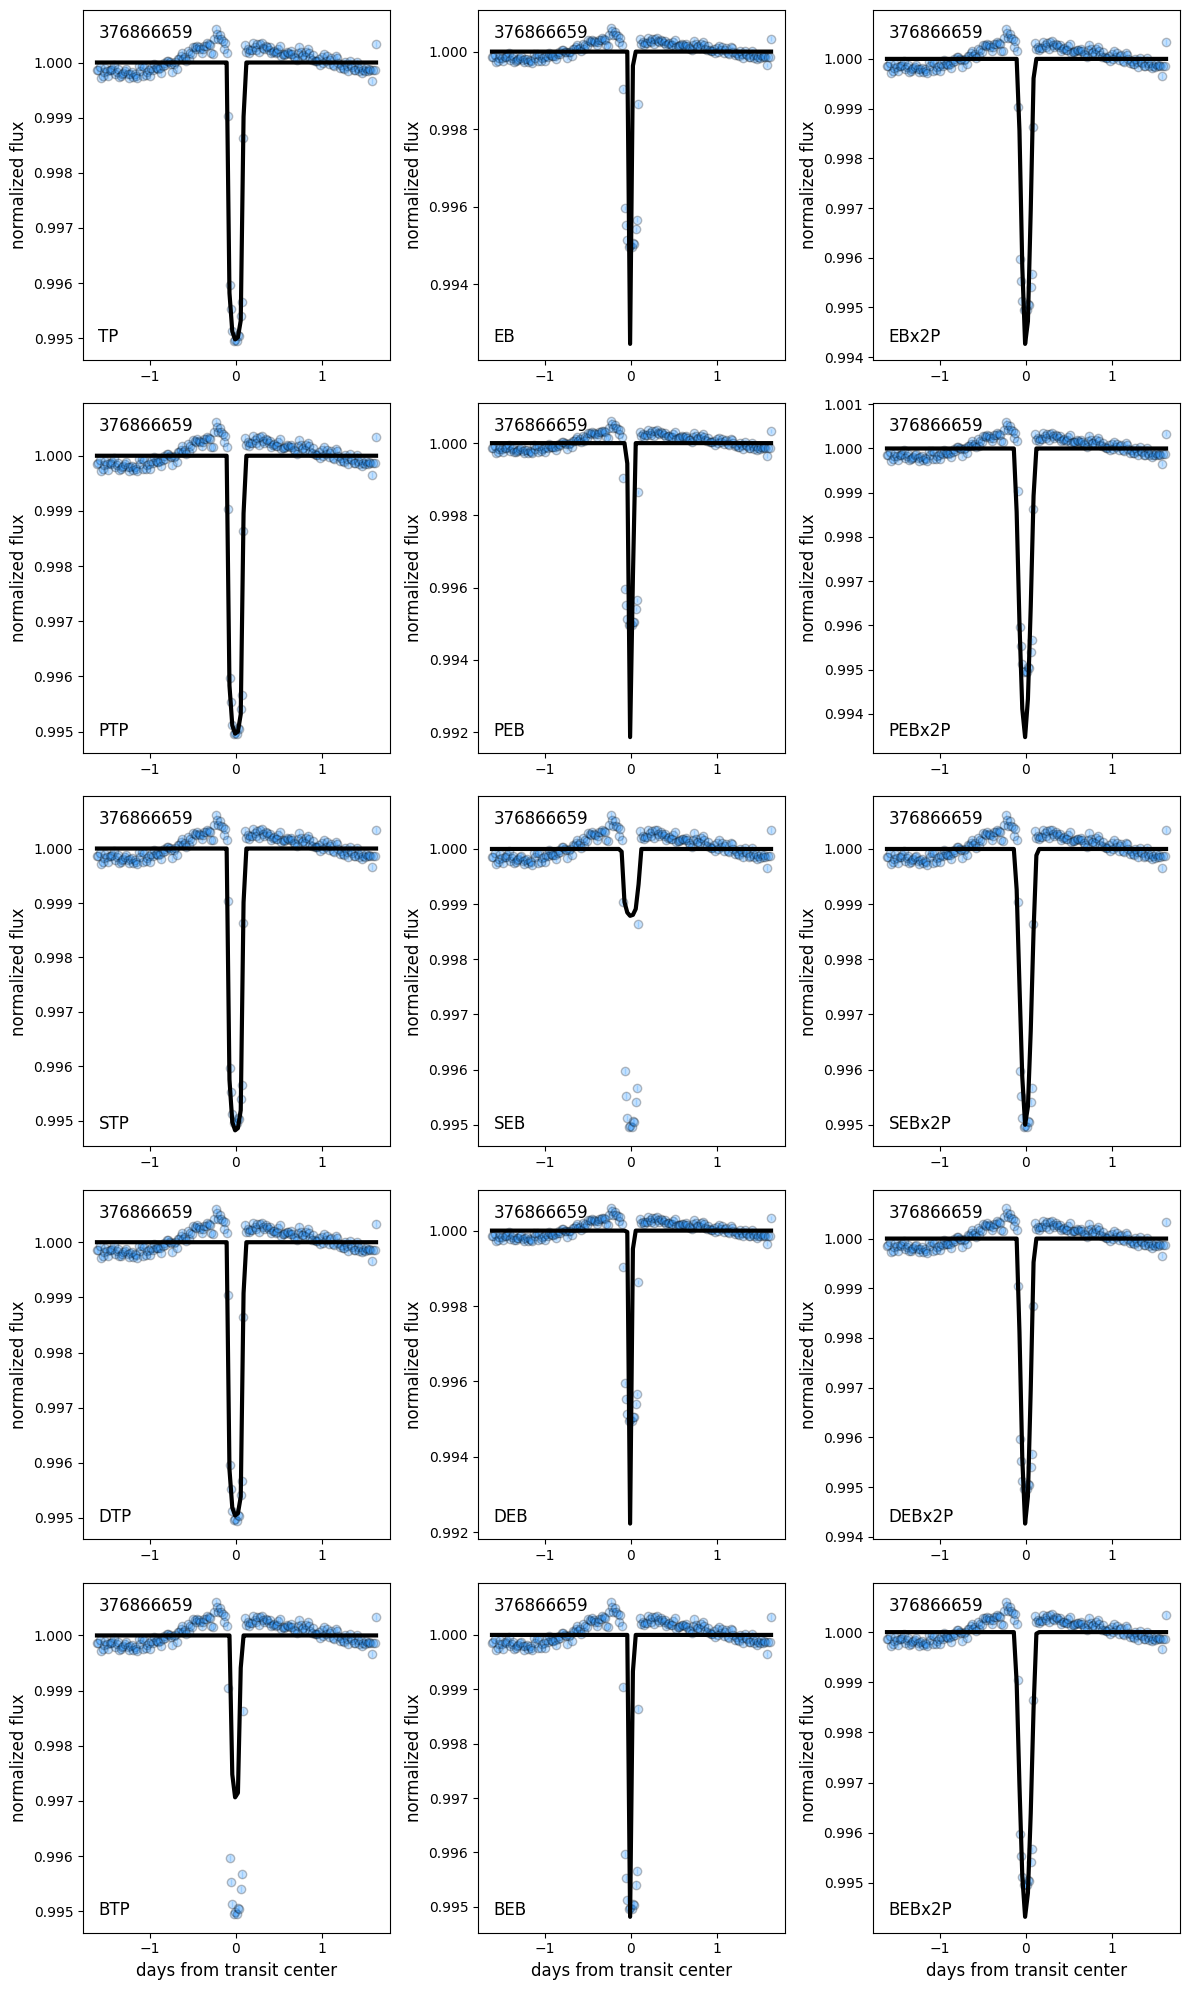

📊 Fit plot saved

▶ RUN 2/20
griz mags: nan nan nan nan
...


C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\triceratops\funcs.py:377: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(output_url, delim_whitespace=True)


Calculating TP scenario probability for 376866659.
Calculating EB and EBx2P scenario probabilities for 376866659.
Z, Teff, logg: 0.0 6500 4.0
Calculating PTP scenario probability for 376866659.
Calculating PEB and PEBx2P scenario probabilities for 376866659.
Calculating STP scenario probability for 376866659.
Calculating SEB and SEBx2P scenario probabilities for 376866659.
Calculating DTP scenario probability for 376866659.
Calculating DEB and DEBx2P scenario probabilities for 376866659.
Calculating BTP scenario probability for 376866659.
Calculating BEB and BEBx2P scenario probabilities for 376866659.
✅ FPP=0.000000, TP=0.939, PTP=0.046, DTP=0.015
💾 Checkpoint saved

▶ RUN 3/20
❌ Unexpected Error: HTTPError: 502 Server Error: Bad Gateway for url: https://mast.stsci.edu/api/v0/invoke
🔄 Retrying run 3...

▶ RUN 3/20
   (Attempt 2/3)
⏳ Waiting 30s before retrying connection...
griz mags: nan nan nan nan


C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\triceratops\funcs.py:377: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(output_url, delim_whitespace=True)


Calculating TP scenario probability for 376866659.
Calculating EB and EBx2P scenario probabilities for 376866659.
Z, Teff, logg: 0.0 6500 4.0
Calculating PTP scenario probability for 376866659.
Calculating PEB and PEBx2P scenario probabilities for 376866659.
Calculating STP scenario probability for 376866659.
Calculating SEB and SEBx2P scenario probabilities for 376866659.
Calculating DTP scenario probability for 376866659.
Calculating DEB and DEBx2P scenario probabilities for 376866659.
Calculating BTP scenario probability for 376866659.
Calculating BEB and BEBx2P scenario probabilities for 376866659.
✅ FPP=0.000000, TP=0.778, PTP=0.188, DTP=0.034
💾 Checkpoint saved

▶ RUN 4/20
griz mags: nan nan nan nan
...


...

Calculating TP scenario probability for 376866659.
Calculating EB and EBx2P scenario probabilities for 376866659.
Z, Teff, logg: 0.0 6500 4.0
Calculating PTP scenario probability for 376866659.
Calculating PEB and PEBx2P scenario probabilities for 376866659.
Calculating STP scenario probability for 376866659.
Calculating SEB and SEBx2P scenario probabilities for 376866659.
Calculating DTP scenario probability for 376866659.
Calculating DEB and DEBx2P scenario probabilities for 376866659.
Calculating BTP scenario probability for 376866659.
Calculating BEB and BEBx2P scenario probabilities for 376866659.
✅ FPP=0.000000, TP=0.861, PTP=0.111, DTP=0.028
💾 Checkpoint saved

▶ RUN 19/20
griz mags: nan nan nan nan


C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\triceratops\funcs.py:377: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(output_url, delim_whitespace=True)


Calculating TP scenario probability for 376866659.
Calculating EB and EBx2P scenario probabilities for 376866659.
Z, Teff, logg: 0.0 6500 4.0
Calculating PTP scenario probability for 376866659.
Calculating PEB and PEBx2P scenario probabilities for 376866659.
Calculating STP scenario probability for 376866659.
Calculating SEB and SEBx2P scenario probabilities for 376866659.
Calculating DTP scenario probability for 376866659.
Calculating DEB and DEBx2P scenario probabilities for 376866659.
Calculating BTP scenario probability for 376866659.
Calculating BEB and BEBx2P scenario probabilities for 376866659.
✅ FPP=0.000000, TP=0.203, PTP=0.155, DTP=0.642
💾 Checkpoint saved

▶ RUN 20/20
griz mags: nan nan nan nan


C:\Users\Usuari\anaconda3\envs\triceratops_plus\lib\site-packages\triceratops\funcs.py:377: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(output_url, delim_whitespace=True)


Calculating TP scenario probability for 376866659.
Calculating EB and EBx2P scenario probabilities for 376866659.
Z, Teff, logg: 0.0 6500 4.0
Calculating PTP scenario probability for 376866659.
Calculating PEB and PEBx2P scenario probabilities for 376866659.
Calculating STP scenario probability for 376866659.
Calculating SEB and SEBx2P scenario probabilities for 376866659.
Calculating DTP scenario probability for 376866659.
Calculating DEB and DEBx2P scenario probabilities for 376866659.
Calculating BTP scenario probability for 376866659.
Calculating BEB and BEBx2P scenario probabilities for 376866659.
✅ FPP=0.000000, TP=0.837, PTP=0.044, DTP=0.119
💾 Checkpoint saved

📊 FINAL STATISTICS
✅ Successful Runs: 20/20
❌ Failed Runs:     0/20

FPP:  Mean = 0.000000, Std Dev = 0.000001
      Min  = -0.000000, Max     = 0.000005

NFPP: Mean = 0.000000, Std Dev = 0.000000

TP:   Mean = 0.449 ± 0.300
PTP:  Mean = 0.325 ± 0.309
DTP:  Mean = 0.226 ± 0.269

SCENARIO WINNER DISTRIBUTION:
TP  wins: 9/2

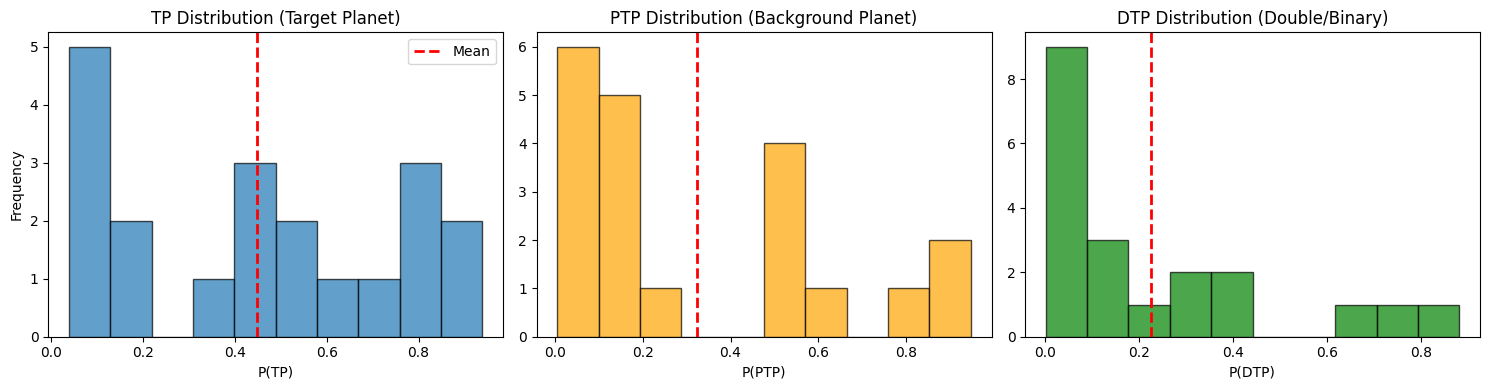

💾 Final data saved: TOI7475_triceratops_20runs_FINAL.csv

🎉 Finished: 2026-02-13 20:06:34


In [6]:
"""
=============================================================================
TRICERATOPS ROBUSTNESS TEST (MULTI-RUN)
=============================================================================

DESCRIPTION:
    Triceratops uses a probabilistic method (MCMC) and connects to an external 
    server (TRILEGAL) to simulate background stars. Because of this:
    1. Results can vary slightly between runs.
    2. The external server sometimes fails or times out.

    This script runs the validation N times (e.g., 20) to ensure the 
    result is STABLE.

    - If FPP is consistently low (< 0.01) across all runs -> ROBUST DETECTION.
    - If FPP jumps around -> UNSTABLE (Caution required).

AUTHOR: Biel Escolà Rodrigo
TARGET: TOI 7475.01 (TIC 376866659)
"""

import numpy as np
import pandas as pd
import lightkurve as lk
import matplotlib.pyplot as plt
import triceratops.triceratops as tr
import os
import time
from datetime import datetime

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
ID = 376866659
sectors = np.array([91])
P_orb = 3.252637    # Period derived from BLS
N_RUNS = 20         # Number of times to repeat the test

print("="*60)
print(f"🦕 TRICERATOPS ROBUSTNESS CHECK - {N_RUNS} RUNS")
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)

# ==============================================================================
# 2. PREPARATION (RUNS ONCE)
# ==============================================================================
print("\n📥 Preparing data...")

# Read the folded light curve (from Script 01)
# Ensure "TOI7475.01_Folded_Raw_GrayPoints.csv" is in the folder
lc_data = pd.read_csv("TOI7475.01_Folded_Raw_GrayPoints.csv", header=None)
time_lc = lc_data[0].values
flux = lc_data[1].values
flux_err = lc_data[2].values

# Bin the data (essential for speed)
lc_binsize = (time_lc.max() - time_lc.min()) / 200
lc_obj = lk.LightCurve(time=time_lc, flux=flux, flux_err=flux_err).bin(time_bin_size=lc_binsize)

# Download TPF to get aperture
tpf = lk.search_targetpixelfile(f"TIC {ID}", sector=91, author="SPOC").download()
mask = tpf.pipeline_mask
ap = np.c_[tpf.column + np.where(mask)[1], tpf.row + np.where(mask)[0]]
apertures = np.array([ap])

# ==============================================================================
# 3. CHECKPOINT SYSTEM
# ==============================================================================
# Checks if a previous run crashed, allowing you to resume instead of restarting.
checkpoint_file = f'TOI7475_checkpoint.csv'

if os.path.exists(checkpoint_file):
    print(f"\n📂 Found previous checkpoint: {checkpoint_file}")
    df_existing = pd.read_csv(checkpoint_file)
    print(f"   Runs previously completed: {len(df_existing)}")
    start_run = len(df_existing) + 1
    results = df_existing.to_dict('records')
else:
    print("\n🆕 Starting validation from scratch")
    start_run = 1
    results = []

# ==============================================================================
# 4. MAIN LOOP (WITH ERROR HANDLING)
# ==============================================================================

for i in range(start_run - 1, N_RUNS):
    run_num = i + 1
    max_retries = 3  # Maximum attempts per run if server fails
    retry_count = 0
    success = False
    
    while retry_count < max_retries and not success:
        try:
            print(f"\n{'='*50}")
            print(f"▶ RUN {run_num}/{N_RUNS}")
            if retry_count > 0:
                print(f"   (Attempt {retry_count + 1}/{max_retries})")
            print('='*50)
            
            # Reset target object
            target = tr.target(ID=ID, sectors=sectors)
            
            # Calculate Depths
            target.calc_depths(tdepth=0.0050, all_ap_pixels=apertures)
            
            # Smart Wait: Pause slightly to avoid banning/saturating the TRILEGAL server
            if retry_count > 0:
                wait_time = retry_count * 30  # Progressive wait on retry
                print(f"⏳ Waiting {wait_time}s before retrying connection...")
                time.sleep(wait_time)
            
            # Calculate Probabilities (The heavy lifting)
            target.calc_probs(
                time=lc_obj.time.value,
                flux_0=lc_obj.flux.value,
                flux_err_0=np.mean(lc_obj.flux_err.value),
                P_orb=P_orb,
                parallel=False
            )
                        
            # Extract Specific Probabilities
            # TP = Transiting Planet
            # PTP = Parasitic Transiting Planet (Background Planet)
            # DTP = Double Transiting Planet (Often false positive)
            tp_prob = target.probs[target.probs['scenario']=='TP']['prob'].values[0]
            ptp_prob = target.probs[target.probs['scenario']=='PTP']['prob'].values[0]
            dtp_prob = target.probs[target.probs['scenario']=='DTP']['prob'].values[0]
            
            results.append({
                'run': run_num,
                'FPP': target.FPP,
                'NFPP': target.NFPP,
                'TP': tp_prob,
                'PTP': ptp_prob,
                'DTP': dtp_prob
            })
            
            print(f"✅ FPP={target.FPP:.6f}, TP={tp_prob:.3f}, PTP={ptp_prob:.3f}, DTP={dtp_prob:.3f}")
            
            success = True  # Mark as successful to exit while loop
            
            # Save Checkpoint immediately
            pd.DataFrame(results).to_csv(checkpoint_file, index=False)
            print(f"💾 Checkpoint saved")
            
            # Save the plot only for the first successful run (to have a visual reference)
            if run_num == 1:
                target.plot_fits(time=lc_obj.time.value, flux_0=lc_obj.flux.value, 
                                flux_err_0=np.mean(lc_obj.flux_err.value))
                plt.savefig('TOI7475_triceratops_fit.png', dpi=300, bbox_inches='tight')
                plt.close()
                print("📊 Fit plot saved")
            
            # Brief pause between successful runs
            if run_num < N_RUNS:
                time.sleep(5) 
        
        except pd.errors.EmptyDataError as e:
            # This usually happens when TRILEGAL returns an empty file
            retry_count += 1
            print(f"❌ TRILEGAL Error (Empty Data): {e}")
            if retry_count < max_retries:
                print(f"🔄 Retrying run {run_num}...")
            else:
                print(f"⚠️ Run {run_num} FAILED after {max_retries} attempts")
                # Append NaN to keep the loop going
                results.append({'run': run_num, 'FPP': np.nan, 'NFPP': np.nan, 'TP': np.nan, 'PTP': np.nan, 'DTP': np.nan})
                pd.DataFrame(results).to_csv(checkpoint_file, index=False)
        
        except Exception as e:
            retry_count += 1
            print(f"❌ Unexpected Error: {type(e).__name__}: {e}")
            if retry_count < max_retries:
                print(f"🔄 Retrying run {run_num}...")
            else:
                print(f"⚠️ Run {run_num} FAILED after {max_retries} attempts")
                results.append({'run': run_num, 'FPP': np.nan, 'NFPP': np.nan, 'TP': np.nan, 'PTP': np.nan, 'DTP': np.nan})
                pd.DataFrame(results).to_csv(checkpoint_file, index=False)

# ==============================================================================
# 5. FINAL STATISTICS
# ==============================================================================
df = pd.DataFrame(results)
df_clean = df.dropna()  # Remove failed runs from statistics
n_success = len(df_clean)
n_failed = N_RUNS - n_success

print("\n" + "="*60)
print(f"📊 FINAL STATISTICS")
print("="*60)
print(f"✅ Successful Runs: {n_success}/{N_RUNS}")
print(f"❌ Failed Runs:     {n_failed}/{N_RUNS}")

if n_success > 0:
    print(f"\nFPP:  Mean = {df_clean['FPP'].mean():.6f}, Std Dev = {df_clean['FPP'].std():.6f}")
    print(f"      Min  = {df_clean['FPP'].min():.6f}, Max     = {df_clean['FPP'].max():.6f}")
    
    print(f"\nNFPP: Mean = {df_clean['NFPP'].mean():.6f}, Std Dev = {df_clean['NFPP'].std():.6f}")
    
    print(f"\nTP:   Mean = {df_clean['TP'].mean():.3f} ± {df_clean['TP'].std():.3f}")
    print(f"PTP:  Mean = {df_clean['PTP'].mean():.3f} ± {df_clean['PTP'].std():.3f}")
    print(f"DTP:  Mean = {df_clean['DTP'].mean():.3f} ± {df_clean['DTP'].std():.3f}")
    
    # Calculate which scenario wins each run (highest probability)
    tp_wins = sum(df_clean[['TP', 'PTP', 'DTP']].idxmax(axis=1) == 'TP')
    ptp_wins = sum(df_clean[['TP', 'PTP', 'DTP']].idxmax(axis=1) == 'PTP')
    dtp_wins = sum(df_clean[['TP', 'PTP', 'DTP']].idxmax(axis=1) == 'DTP')
    
    print(f"\n{'='*60}")
    print("SCENARIO WINNER DISTRIBUTION:")
    print('='*60)
    print(f"TP  wins: {tp_wins}/{n_success} times ({tp_wins/n_success*100:.1f}%)")
    print(f"PTP wins: {ptp_wins}/{n_success} times ({ptp_wins/n_success*100:.1f}%)")
    print(f"DTP wins: {dtp_wins}/{n_success} times ({dtp_wins/n_success*100:.1f}%)")
    
    print(f"\n✅ STABILITY CHECK: {sum(df_clean['FPP'] < 0.01)}/{n_success} runs have FPP < 0.01")
    
    # ==============================================================================
    # 6. HISTOGRAMS
    # ==============================================================================
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].hist(df_clean['TP'], bins=10, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('P(TP)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'TP Distribution (Target Planet)')
    axes[0].axvline(df_clean['TP'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[0].legend()
    
    axes[1].hist(df_clean['PTP'], bins=10, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_xlabel('P(PTP)')
    axes[1].set_title(f'PTP Distribution (Background Planet)')
    axes[1].axvline(df_clean['PTP'].mean(), color='red', linestyle='--', linewidth=2)
    
    axes[2].hist(df_clean['DTP'], bins=10, edgecolor='black', alpha=0.7, color='green')
    axes[2].set_xlabel('P(DTP)')
    axes[2].set_title(f'DTP Distribution (Double/Binary)')
    axes[2].axvline(df_clean['DTP'].mean(), color='red', linestyle='--', linewidth=2)
    
    plt.tight_layout()
    plt.savefig(f'TOI7475_triceratops_{n_success}runs_histograms.png', dpi=300, bbox_inches='tight')
    print(f"\n📊 Histograms saved successfully.")
    plt.show()

else:
    print("\n⚠️ No successful runs. Check your internet connection or try again later.")

# ==============================================================================
# 7. SAVE FINAL CSV
# ==============================================================================
df.to_csv(f'TOI7475_triceratops_{N_RUNS}runs_FINAL.csv', index=False)
print(f"💾 Final data saved: TOI7475_triceratops_{N_RUNS}runs_FINAL.csv")

print(f"\n🎉 Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")